# 02 - Results

Model comparison, equity finding and the figures used in the report. Run the ML
and viz stages first so the CSVs under `docs/results/` exist.

In [1]:
import sys; sys.path.append('..')
import pandas as pd
from src.common import project_path
metrics = pd.read_csv(project_path('docs', 'results', 'metrics.csv'))
metrics

,model,accuracy,precision,recall,f1,roc_auc,pr_auc,train_seconds,f1_per_sec
0,logistic_regression,0.740224,0.722876,0.740224,0.728231,0.725067,0.494844,14.69,0.04957
1,random_forest,0.768786,0.749181,0.768786,0.745583,0.762557,0.534251,20.17,0.03696
2,gbt,0.765046,0.746065,0.765046,0.747174,0.753306,0.530101,54.78,0.01364


## Model Efficiency: F1 per training-second

In [2]:
metrics[['model', 'f1', 'roc_auc', 'pr_auc', 'train_seconds', 'f1_per_sec']]

,model,f1,roc_auc,pr_auc,train_seconds,f1_per_sec
0,logistic_regression,0.728231,0.725067,0.494844,14.69,0.04957
1,random_forest,0.745583,0.762557,0.534251,20.17,0.03696
2,gbt,0.747174,0.753306,0.530101,54.78,0.01364


## The equity finding: compliance by deprivation decile

In [3]:
from src.db.queries import connect, compliance_by_imd_decile
conn = connect()
eq = pd.DataFrame([dict(r) for r in compliance_by_imd_decile(conn)])
conn.close()
eq

,imd_decile,compliance_rate,band_days
0,1,0.248220,983
1,2,0.249508,2032
2,3,0.275328,1678
3,4,0.282480,1016
4,5,0.240909,1320
5,6,0.321591,880
6,7,0.251969,762
7,8,0.302285,569
8,9,0.269504,141
9,10,0.355263,152


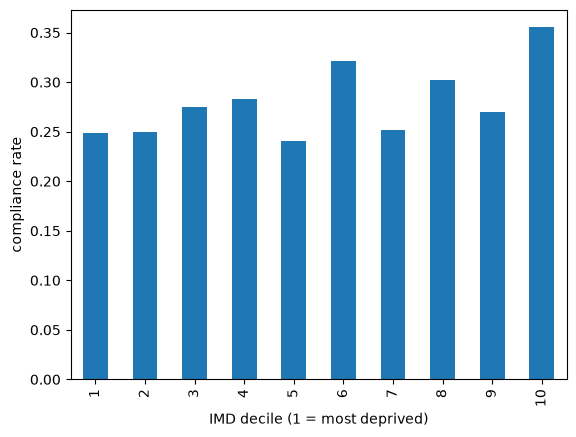

In [4]:
ax = eq.plot(x='imd_decile', y='compliance_rate', kind='bar', legend=False)
ax.set_xlabel('IMD decile (1 = most deprived)'); ax.set_ylabel('compliance rate');